# Loan Approval Prediction — Model Training, Comparison, Tuning & Evaluation

**Train and tune** seven classifiers, compare them with
cross-validation and held-out test metrics, and save the best-performing
model for the Streamlit app.

**Input:** `data/loan_approval_selected.csv` (10 features + target).

 **`cibil_score`** is by far the strongest individual
predictor (correlation 0.77 with the target).


In [1]:
import sys
sys.path.append("..")
sys.path.append("../src")

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from train import load_and_split, fit_scaler, MODEL_GRID, tune_model, select_best_model
from evaluate import evaluate_model, print_evaluation_report, plot_confusion_matrix

sns.set_style("whitegrid")


## 1. Stratified Train/Test Split

In [2]:
X_train, X_test, y_train, y_test = load_and_split(data_path="../data/loan_approval_selected.csv")
print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Train target balance:\n{y_train.value_counts(normalize=True).round(3)}")
print(f"Test target balance:\n{y_test.value_counts(normalize=True).round(3)}")


Train: (3415, 10), Test: (854, 10)
Train target balance:
loan_status
1    0.622
0    0.378
Name: proportion, dtype: float64
Test target balance:
loan_status
1    0.622
0    0.378
Name: proportion, dtype: float64


Stratification preserves the original class distribution (62% Approved and 38% Rejected) in both the training and testing datasets. This ensures that model performance is evaluated on representative data and produces more reliable and unbiased results.

## 2. Scale Features (fit on training data only)

In [3]:
scaler = fit_scaler(X_train)
X_train_scaled = pd.DataFrame(scaler.transform(X_train), columns=X_train.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)
print("Scaler fit on training data only — test set statistics never seen during fitting.")


Scaler fit on training data only — test set statistics never seen during fitting.


## 3. Train & Tune All Models (5-fold CV, optimizing F1)

In [4]:
all_results = []
for name, config in MODEL_GRID.items():
    result = tune_model(name, config["estimator"], config["params"], X_train_scaled, y_train)
    metrics = evaluate_model(name, result["best_estimator"], X_test_scaled, y_test)
    all_results.append({**result, **metrics})
    print(f"{name}: CV F1={result['best_cv_f1']:.4f} | Test F1={metrics['f1']:.4f} | Test ROC-AUC={metrics['roc_auc']:.4f}")


Logistic Regression: CV F1=0.9296 | Test F1=0.9354 | Test ROC-AUC=0.9737
Decision Tree: CV F1=0.9998 | Test F1=1.0000 | Test ROC-AUC=1.0000
Random Forest: CV F1=0.9988 | Test F1=0.9991 | Test ROC-AUC=1.0000
KNN: CV F1=0.9327 | Test F1=0.9430 | Test ROC-AUC=0.9824
Naive Bayes: CV F1=0.9435 | Test F1=0.9542 | Test ROC-AUC=0.9780
SVM: CV F1=0.9621 | Test F1=0.9709 | Test ROC-AUC=0.9952
XGBoost: CV F1=0.9981 | Test F1=0.9972 | Test ROC-AUC=1.0000


## 4. Model Comparison Table

In [5]:
comparison = pd.DataFrame([{
    "Model": r["name"],
    "CV F1": r["best_cv_f1"],
    "Test Accuracy": r["accuracy"],
    "Test Precision": r["precision"],
    "Test Recall": r["recall"],
    "Test F1": r["f1"],
    "Test ROC-AUC": r["roc_auc"],
} for r in all_results]).sort_values("Test F1", ascending=False).reset_index(drop=True)

comparison


,Model,CV F1,Test Accuracy,Test Precision,Test Recall,Test F1,Test ROC-AUC
0,Decision Tree,0.999765,1.000000,1.000000,1.000000,1.000000,1.000000
1,Random Forest,0.998823,0.998829,0.998120,1.000000,0.999059,1.000000
2,XGBoost,0.998117,0.996487,0.994382,1.000000,0.997183,1.000000
3,SVM,0.962121,0.963700,0.968165,0.973635,0.970892,0.995155
4,Naive Bayes,0.943476,0.942623,0.947955,0.960452,0.954163,0.978031
5,KNN,0.932706,0.928571,0.935185,0.951036,0.943044,0.982351
6,Logistic Regression,0.929559,0.918033,0.916817,0.954802,0.935424,0.973705


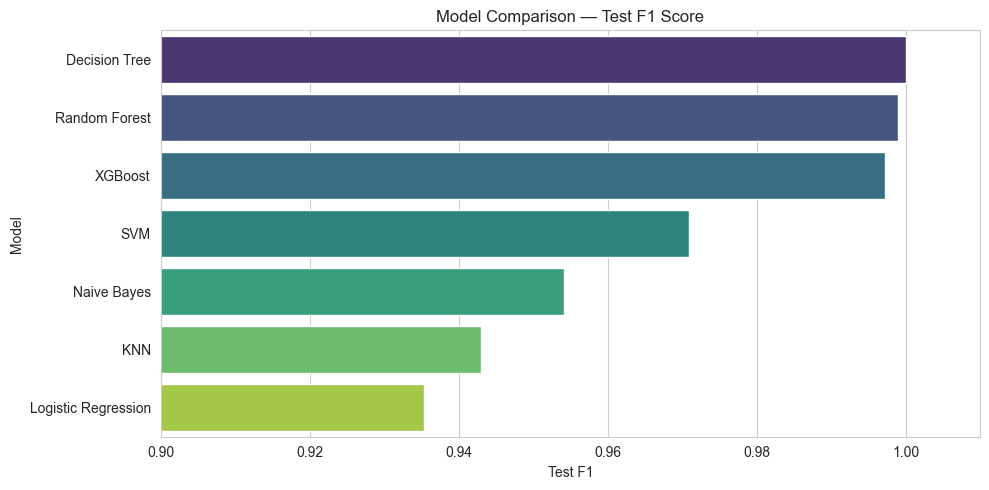

In [6]:
plt.figure(figsize=(10, 5))
sns.barplot(data=comparison, x="Test F1", y="Model", palette="viridis")
plt.title("Model Comparison — Test F1 Score")
plt.xlim(0.9, 1.01)
plt.tight_layout()
plt.savefig("../images/day4_model_comparison.png", dpi=100)
plt.show()


## 5. Confusion Matrices — All Models

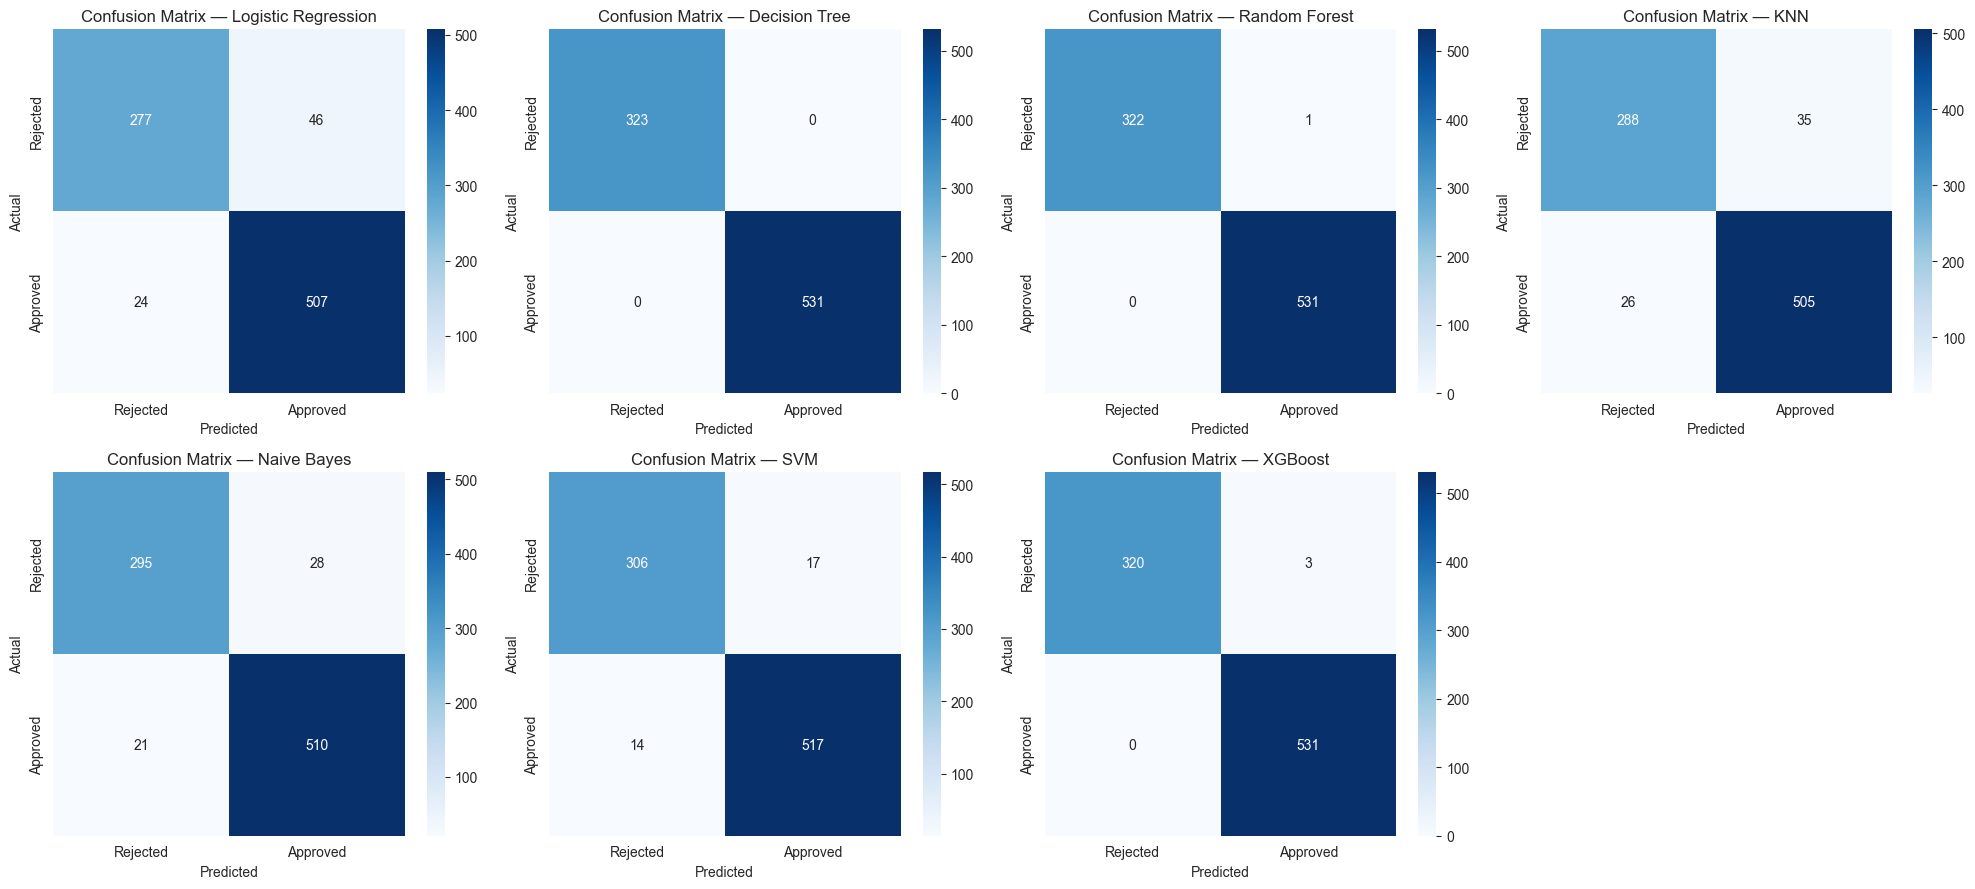

In [7]:
fig, axes = plt.subplots(2, 4, figsize=(20, 9))
axes = axes.flatten()
for i, r in enumerate(all_results):
    plot_confusion_matrix(r["name"], y_test, r["y_pred"], ax=axes[i])
for j in range(len(all_results), len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.savefig("../images/day4_confusion_matrices.png", dpi=100)
plt.show()
